In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)

def load_spambase(data_path, names_path):
    feature_names = []
    with open(names_path, 'r', encoding='utf-8') as f:
        for raw in f:
            line = raw.strip()
            left = line.split(':', 1)[0].strip()
            if left.startswith('word_freq_') or left.startswith('char_freq_') or left.startswith('capital_run_length_'):
                feature_names.append(left)

    arr = np.loadtxt(data_path, delimiter=',')
    X = arr[:, :-1].astype(float)
    y = arr[:, -1].astype(int)
    return X, y, feature_names

X, y, feature_names = load_spambase('spambase.data', 'spambase.names')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

def classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    err = 1.0 - acc
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return acc, err, prec, rec, f1

def predict_from_threshold(proba_1d, threshold):
    return (proba_1d >= threshold)

In [2]:
# Problem 1
logreg = LogisticRegression()
logreg.fit(X_train_s, y_train)

test_proba = logreg.predict_proba(X_test_s)[:, 1]
y_test_pred = predict_from_threshold(test_proba, 0.5)

cm = confusion_matrix(y_test, y_test_pred)
acc, err, prec, rec, f1 = classification_metrics(y_test, y_test_pred)

print('Confusion matrix:')
print(cm)
print()
print(f'Accuracy: {acc}')
print(f'Error: {err}')
print(f'Precision: {prec}')
print(f'Recall: {rec}')
print(f'F1 score: {f1}')


Confusion matrix:
[[660  37]
 [ 40 414]]

Accuracy: 0.9331016507384883
Error: 0.06689834926151172
Precision: 0.917960088691796
Recall: 0.9118942731277533
F1 score: 0.9149171270718232


In [3]:
coefs = logreg.coef_.ravel()
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df['abs_coef'] = np.abs(coef_df['coef'])

top_pos = coef_df[coef_df['coef'] > 0].sort_values('abs_coef', ascending=False)
top_neg = coef_df[coef_df['coef'] < 0].sort_values('abs_coef', ascending=False)

print('Positive coefficients:')
for feature, coef_val in zip(top_pos['feature'], top_pos['coef']):
    print(f"{feature}: {coef_val}")
print()
print('Negative coefficients:')
for feature, coef_val in zip(top_neg['feature'], top_neg['coef']):
    print(f"{feature}: {coef_val}")

print()
print('Coefficients:')
top = coef_df.sort_values('abs_coef', ascending=False)
print(top[['feature', 'coef']])


Positive coefficients:
capital_run_length_average: 1.2236132475266412
capital_run_length_longest: 0.9991658921806995
char_freq_$: 0.9790036609796713
word_freq_000: 0.9680938006479416
word_freq_remove: 0.9272496948854132
word_freq_3d: 0.9046486919744191
word_freq_credit: 0.7511977649238012
char_freq_#: 0.6752429200773188
word_freq_free: 0.6366610058492732
char_freq_!: 0.602084695284951
capital_run_length_total: 0.5075863908561834
word_freq_technology: 0.46867701347017304
word_freq_business: 0.4550646335051586
word_freq_our: 0.409502202349824
word_freq_your: 0.2842628962879117
word_freq_internet: 0.24391989262229946
word_freq_money: 0.1869466354480785
word_freq_addresses: 0.17978681103102237
word_freq_650: 0.17519909376395734
word_freq_mail: 0.13497431470195242
word_freq_font: 0.11844897736393646
word_freq_order: 0.10199246497869847
word_freq_over: 0.09698975478891901
word_freq_you: 0.0920369023014613
word_freq_parts: 0.08701795800855466
word_freq_email: 0.06521452616049422
word_freq_all

In [4]:
thresholds = [0.25, 0.5, 0.75, 0.9]
rows = []
for t in thresholds:
    y_pred = predict_from_threshold(test_proba, t)
    acc, err, prec, rec, f1 = classification_metrics(y_test, y_pred)
    rows.append({
        'T': t,
        'accuracy': acc,
        'error': err,
        'precision': prec,
        'recall': rec,
        'F1': f1,
    })

tbl = pd.DataFrame(rows)
print(tbl)


      T  accuracy     error  precision    recall        F1
0  0.25  0.917463  0.082537   0.844530  0.969163  0.902564
1  0.50  0.933102  0.066898   0.917960  0.911894  0.914917
2  0.75  0.900956  0.099044   0.945026  0.795154  0.863636
3  0.90  0.836664  0.163336   0.946309  0.621145  0.750000


In [5]:
# Problem 2
learning_rates = [0.1, 0.01, 0.001]

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def cross_entropy_loss(y_true, proba_1d):
    eps = 1e-15
    p = np.clip(proba_1d, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

def gradient_descent_logreg(X_train_s, y_train, lr, n_iters=100):
    m, n = X_train_s.shape
    Xb = np.ones((m, n + 1))
    Xb[:, 1:] = X_train_s
    w = np.zeros(n + 1)
    checkpoints = {10, 50, 100}
    losses = {}
    for it in range(1, n_iters + 1):
        z = Xb @ w
        p = sigmoid(z)
        grad = (Xb.T @ (p - y_train)) / m
        w -= lr * grad
        if it in checkpoints:
            losses[it] = cross_entropy_loss(y_train, p)
    return w, losses

def predict_proba_gd(X_s, w):
    Xb = np.ones((X_s.shape[0], X_s.shape[1] + 1))
    Xb[:, 1:] = X_s
    return sigmoid(Xb @ w)

gd_rows = []
for lr in learning_rates:
    w, losses = gradient_descent_logreg(X_train_s, y_train, lr=lr, n_iters=100)
    p_train = predict_proba_gd(X_train_s, w)
    p_test = predict_proba_gd(X_test_s, w)

    y_train_pred = (p_train >= 0.5)
    y_test_pred = (p_test >= 0.5)

    train_accuracy, train_error, train_precision, train_recall, train_f1 = classification_metrics(y_train, y_train_pred)
    test_accuracy, test_error, test_precision, test_recall, test_f1 = classification_metrics(y_test, y_test_pred)

    gd_rows.append({
        'learning_rate': lr,
        'loss at 10': losses[10],
        'loss at 50': losses[50],
        'loss at 100': losses[100],
        'train_accuracy': train_accuracy,
        'train_precision': train_precision,
        'train_recall': train_recall,
        'train_F1': train_f1,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_F1': test_f1,
    })

gd_df = pd.DataFrame(gd_rows)
print(gd_df)

print()
print('Package metrics:')
package_train_pred = (logreg.predict_proba(X_train_s)[:, 1] >= 0.5)
package_test_pred = (logreg.predict_proba(X_test_s)[:, 1] >= 0.5)
train_accuracy, train_error, train_precision, train_recall, train_f1 = classification_metrics(y_train, package_train_pred)
test_accuracy, test_error, test_precision, test_recall, test_f1 = classification_metrics(y_test, package_test_pred)
print(f'Train accuracy: {train_accuracy} error: {train_error} precision: {train_precision} recall: {train_recall} F1: {train_f1}')
print(f'Test accuracy: {test_accuracy} error: {test_error} precision: {test_precision} recall: {test_recall} F1: {test_f1}')


   learning_rate  loss at 10  loss at 50  loss at 100  train_accuracy  \
0          0.100    0.469851    0.319476     0.283304        0.910725   
1          0.010    0.652860    0.537649     0.463166        0.904928   
2          0.001    0.688785    0.670374     0.649414        0.900000   

   train_precision  train_recall  train_F1  test_accuracy  test_precision  \
0         0.918059      0.849154  0.882263       0.921807        0.919355   
1         0.889057      0.866814  0.877794       0.913988        0.908046   
2         0.871157      0.875644  0.873394       0.915725        0.895787   

   test_recall   test_F1  
0     0.878855  0.898649  
1     0.870044  0.888639  
2     0.889868  0.892818  

Package metrics:
Train accuracy: 0.9298550724637681 error: 0.07014492753623192 precision: 0.9266615737203973 recall: 0.8925680647534953 F1: 0.9092953523238381
Test accuracy: 0.9331016507384883 error: 0.06689834926151172 precision: 0.917960088691796 recall: 0.9118942731277533 F1: 0.9149171

In [6]:

k_candidates = [1, 3, 5, 7, 9, 11, 15]
n_splits = 5

skf = StratifiedKFold(n_splits=n_splits)

rows = []
for k in k_candidates:
    fold_metrics = []
    for train_index, val_index in skf.split(X_train_s, y_train):
        Xtr, Xval = X_train_s[train_index], X_train_s[val_index]
        ytr, yval = y_train[train_index], y_train[val_index]
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(Xtr, ytr)
        yval_pred = knn.predict(Xval)
        acc, err, prec, rec, f1 = classification_metrics(yval, yval_pred)
        fold_metrics.append((acc, err, prec, rec, f1))

    fold_metrics = np.array(fold_metrics, dtype=float)
    mean_acc = fold_metrics[:, 0].mean()
    mean_err = fold_metrics[:, 1].mean()
    mean_prec = fold_metrics[:, 2].mean()
    mean_rec = fold_metrics[:, 3].mean()
    rows.append({
        'k': k,
        'val_accuracy': mean_acc,
        'val_error': mean_err,
        'val_precision': mean_prec,
        'val_recall': mean_rec,
    })

knn_df = pd.DataFrame(rows)
print(knn_df)

best_row = knn_df.sort_values('val_error', ascending=True).iloc[0]
best_k = int(best_row['k'])
print()
print(f'Selected k (min avg CV error): {best_k}')


    k  val_accuracy  val_error  val_precision  val_recall
0   1      0.902899   0.097101       0.880664    0.871945
1   3      0.903188   0.096812       0.888686    0.862394
2   5      0.900000   0.100000       0.890257    0.851370
3   7      0.900580   0.099420       0.893868    0.848424
4   9      0.906377   0.093623       0.903565    0.853565
5  11      0.900870   0.099130       0.905294    0.835910
6  15      0.899710   0.100290       0.905575    0.832239

Selected k (min avg CV error): 9


In [7]:
# Problem 3
logreg = LogisticRegression()
logreg.fit(X_train_s, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_s, y_train)

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_s, y_train)

def metrics_for_model(model):
    train_positive_probabilities = model.predict_proba(X_train_s)[:, 1]
    test_positive_probabilities = model.predict_proba(X_test_s)[:, 1]
    ytr_pred = predict_from_threshold(train_positive_probabilities, 0.5)
    yte_pred = predict_from_threshold(test_positive_probabilities, 0.5)
    train_metrics = classification_metrics(y_train, ytr_pred)
    test_metrics = classification_metrics(y_test, yte_pred)
    return train_metrics, test_metrics

models = {
    'LogisticRegression': logreg,
    'LDA': lda,
    'kNN': knn_best,
}

rows = []
for name, model in models.items():
    (train_accuracy, train_error, train_precision, train_recall, train_f1), (test_accuracy, test_error, test_precision, test_recall, test_f1) = metrics_for_model(model)
    rows.append({
        'model': name,
        'train_accuracy': train_accuracy,
        'train_error': train_error,
        'train_precision': train_precision,
        'train_recall': train_recall,
        'train_F1': train_f1,
        'test_accuracy': test_accuracy,
        'test_error': test_error,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_F1': test_f1,
    })

model_comparison_df = pd.DataFrame(rows)
print(model_comparison_df)

best_model = model_comparison_df.sort_values('test_accuracy', ascending=False).iloc[0]['model']
worst_model = model_comparison_df.sort_values('test_accuracy', ascending=True).iloc[0]['model']
print()
print(f'Best (by test accuracy): {best_model}')
print(f'Worst (by test accuracy): {worst_model}')


                model  train_accuracy  train_error  train_precision  \
0  LogisticRegression        0.929855     0.070145         0.926662   
1                 LDA        0.888986     0.111014         0.921416   
2                 kNN        0.921449     0.078551         0.919106   

   train_recall  train_F1  test_accuracy  test_error  test_precision  \
0      0.892568  0.909295       0.933102    0.066898        0.917960   
1      0.785136  0.847835       0.898349    0.101651        0.920200   
2      0.877851  0.898005       0.909644    0.090356        0.906977   

   test_recall   test_F1  
0     0.911894  0.914917  
1     0.812775  0.863158  
2     0.859031  0.882353  

Best (by test accuracy): LogisticRegression
Worst (by test accuracy): LDA


ROC AUC: 0.9722


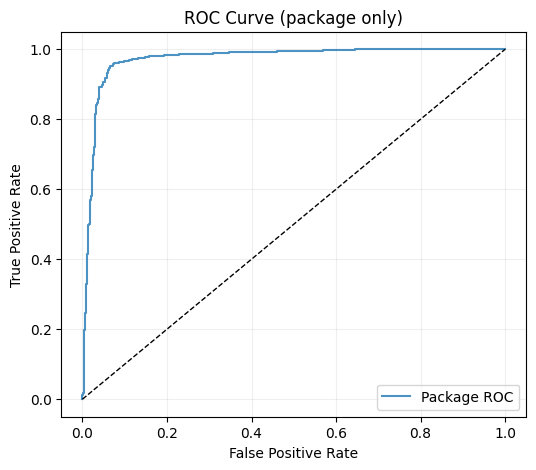

In [8]:
probs = logreg.predict_proba(X_test_s)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
print(f'ROC AUC: {roc_auc:.4f}')

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="Package ROC", alpha=0.8)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (package only)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

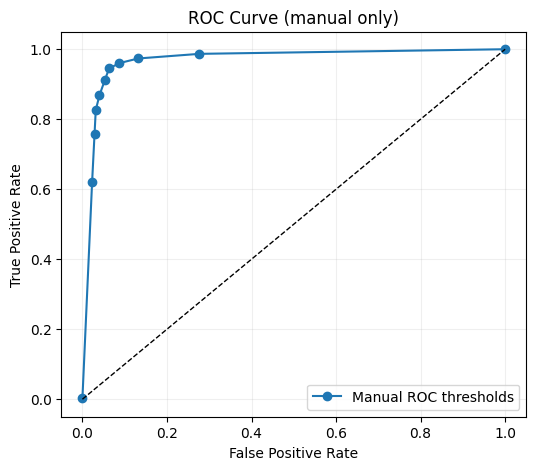

In [9]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

roc_false_positive_rate_values = []
roc_true_positive_rate_values = []

for t in thresholds:
    y_hat = predict_from_threshold(probs, t)

    cm = confusion_matrix(y_test, y_hat, labels=[0, 1])
    true_negative, false_positive, false_negative, true_positive = cm.ravel()

    false_positive_rate_at_threshold = false_positive / (false_positive + true_negative)
    true_positive_rate_at_threshold = true_positive / (true_positive + false_negative)

    roc_false_positive_rate_values.append(false_positive_rate_at_threshold)
    roc_true_positive_rate_values.append(true_positive_rate_at_threshold)

plt.figure(figsize=(6, 5))
plt.plot(
    roc_false_positive_rate_values,
    roc_true_positive_rate_values,
    marker="o",
    linestyle="-",
    label="Manual ROC thresholds"
)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (manual only)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

      T       FPR       TPR
0   0.0  1.000000  1.000000
1   0.1  0.276901  0.986784
2   0.2  0.131994  0.973568
3   0.3  0.087518  0.960352
4   0.4  0.063128  0.944934
5   0.5  0.053085  0.911894
6   0.6  0.040172  0.867841
7   0.7  0.031564  0.825991
8   0.8  0.028694  0.757709
9   0.9  0.022956  0.621145
10  1.0  0.000000  0.002203
ROC AUC: 0.9722


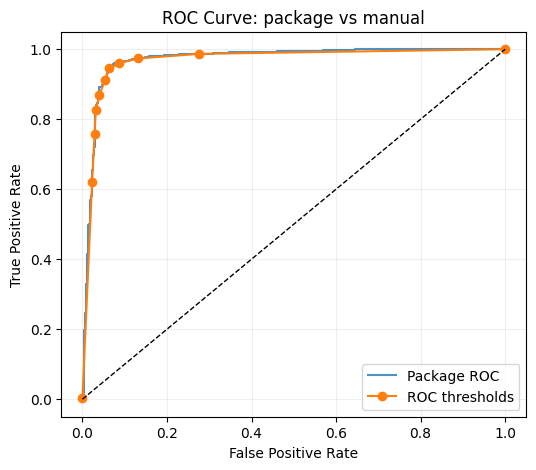

In [10]:
probs = logreg.predict_proba(X_test_s)[:, 1]
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

roc_rows = []
roc_false_positive_rate_values = []
roc_true_positive_rate_values = []

for t in thresholds:
    y_hat = predict_from_threshold(probs, t)
    cm = confusion_matrix(y_test, y_hat, labels=[0, 1])
    true_negative, false_positive, false_negative, true_positive = cm.ravel()
    false_positive_rate_at_threshold = false_positive / (false_positive + true_negative)
    true_positive_rate_at_threshold = true_positive / (true_positive + false_negative)
    roc_rows.append({'T': t, 'FPR': false_positive_rate_at_threshold, 'TPR': true_positive_rate_at_threshold})
    roc_false_positive_rate_values.append(false_positive_rate_at_threshold)
    roc_true_positive_rate_values.append(true_positive_rate_at_threshold)

roc_df = pd.DataFrame(roc_rows)
print(roc_df)

plt.figure(figsize=(6, 5))
fpr, tpr, roc_thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
print(f'ROC AUC: {roc_auc:.4f}')
plt.plot(fpr, tpr, label='Package ROC', alpha=0.8)
plt.plot(roc_false_positive_rate_values, roc_true_positive_rate_values, marker='o', linestyle='-', label='ROC thresholds')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: package vs manual')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.2)
plt.show()


In [11]:
# Problem 4
def kfold_cv_indices(n, k):
    index = np.arange(n)
    parts = []
    fold_size = n // k
    remainder = n % k
    start = 0
    for i in range(k):
        extra = 1 if i < remainder else 0
        end = start + fold_size + extra
        parts.append(index[start:end])
        start = end
    return parts

def cv_error_logreg_lda(X_raw, y, k, model_type):
    n = X_raw.shape[0]
    parts = kfold_cv_indices(n, k)
    fold_errors = []
    for i in range(k):
        val_index = parts[i]
        mask = np.ones(n, dtype=bool)
        mask[val_index] = False
        train_index = np.arange(n)[mask]

        Xtr_raw, Xval_raw = X_raw[train_index], X_raw[val_index]
        ytr, yval = y[train_index], y[val_index]

        scaler = StandardScaler()
        Xtr = scaler.fit_transform(Xtr_raw)
        Xval = scaler.transform(Xval_raw)

        if model_type == 'logreg':
            model = LogisticRegression()
        else:
            model = LinearDiscriminantAnalysis()

        model.fit(Xtr, ytr)
        yval_pred = (model.predict_proba(Xval)[:, 1] >= 0.5)

        acc = accuracy_score(yval, yval_pred)
        fold_errors.append(1.0 - acc)

    return float(np.mean(fold_errors))

k_values = [5, 10]
for k in k_values:
    err_logreg = cv_error_logreg_lda(X, y, k=k, model_type='logreg')
    err_lda = cv_error_logreg_lda(X, y, k=k, model_type='lda')
    print('k =', k, 'Logistic Regression avg validation error =', err_logreg)
    print('k =', k, 'LDA avg validation error =', err_lda)
    if err_logreg < err_lda:
        print('Logistic Regression performs better (lower error).')
    else:
        print('LDA performs better (lower error).')
    print()


k = 5 Logistic Regression avg validation error = 0.1416968795732427
k = 5 LDA avg validation error = 0.1838320823301704
Logistic Regression performs better (lower error).

k = 10 Logistic Regression avg validation error = 0.10952796378383475
k = 10 LDA avg validation error = 0.1479661416580213
Logistic Regression performs better (lower error).

